In [6]:
import pandas as pd 
import numpy as np

# DATA PREPROCESSING

In [7]:
people = pd.read_csv("01_people.csv")
abilities = pd.read_csv("02_abilities.csv")
education = pd.read_csv("03_education.csv")
experience = pd.read_csv("04_experience.csv")  
person_skills = pd.read_csv("05_person_skills.csv")
skills = pd.read_csv("06_skills.csv")
job_descriptions = pd.read_csv("job_descriptions.csv")


In [8]:
print(people.shape)
print(abilities.shape)
print(education.shape)
print(experience.shape)
print(person_skills.shape)
print(skills.shape)

(54933, 5)
(1219473, 2)
(75999, 5)
(265404, 6)
(2483376, 2)
(226760, 1)


In [9]:
people.head()

,person_id,name,email,phone,linkedin
0,1,Database Administrator,NaN,NaN,NaN
1,2,Database Administrator,NaN,NaN,NaN
2,3,Oracle Database Administrator,NaN,NaN,NaN
3,4,Amazon Redshift Administrator and ETL Develope...,NaN,NaN,NaN
4,5,Scrum Master Scrum Master Scrum Master,NaN,NaN,NaN


In [10]:
print("People:")
print(people.columns)

print("\nAbilities:")
print(abilities.columns)

print("\nEducation:")
print(education.columns)

print("\nExperience:")
print(experience.columns)

print("\nPerson Skills:")
print(person_skills.columns)

print("\nSkills:")
print(skills.columns)

People:
Index(['person_id', 'name', 'email', 'phone', 'linkedin'], dtype='str')

Abilities:
Index(['person_id', 'ability'], dtype='str')

Education:
Index(['person_id', 'institution', 'program', 'start_date', 'location'], dtype='str')

Experience:
Index(['person_id', 'title', 'firm', 'start_date', 'end_date', 'location'], dtype='str')

Person Skills:
Index(['person_id', 'skill'], dtype='str')

Skills:
Index(['skill'], dtype='str')


In [11]:
education_text = (
    education.groupby("person_id")
    .agg({
        "institution": lambda x: " | ".join(
            x.dropna().astype(str)
        ),
        "program": lambda x: " | ".join(
            x.dropna().astype(str)
        )
    })
    .reset_index()
)

In [12]:
experience_text = (
    experience.groupby("person_id")
    .agg({
        "title": lambda x: " | ".join(
            x.dropna().astype(str)
        ),
        "firm": lambda x: " | ".join(
            x.dropna().astype(str)
        ), 
        "start_date": lambda x: " | ".join(
            x.dropna().astype(str)
        ),
        "end_date": lambda x: " | ".join(
            x.dropna().astype(str)
        )
    })
    .reset_index()
)

In [13]:
skills_text = (
    person_skills.groupby("person_id")["skill"]
    .apply(lambda x: ", ".join(
        x.dropna().astype(str)
    ))
    .reset_index()
)

skills_text.rename(
    columns={"skill": "skills"},
    inplace=True
)

In [14]:
abilities_text = (
    abilities.groupby("person_id")["ability"]
    .apply(lambda x: ", ".join(
        x.dropna().astype(str)
    ))
    .reset_index()
)

abilities_text.rename(
    columns={"ability": "abilities"},
    inplace=True
)

In [15]:
resume_df = people.copy()

resume_df = resume_df.merge(
    education_text,
    on="person_id",
    how="left"
)

resume_df = resume_df.merge(
    experience_text,
    on="person_id",
    how="left"
)

resume_df = resume_df.merge(
    skills_text,
    on="person_id",
    how="left"
)
resume_df = resume_df.merge(
    abilities_text,
    on="person_id",
    how="left"
)

In [16]:
resume_df["resume_text"] = (
    resume_df["institution"].fillna("") + " " +
    resume_df["program"].fillna("") + " " +
    resume_df["title"].fillna("") + " " +
    resume_df["firm"].fillna("") + " " +
    resume_df["skills"].fillna("") + " " +
    resume_df["abilities"].fillna("")+ " " + 
    resume_df["start_date"].fillna("")+ " " +
    resume_df["end_date"].fillna("")+ " "
    
)

In [17]:
resume_df.to_csv(
    "Resume_dataset.csv",
    index=False
)

In [18]:
resume_df.head()

,person_id,name,email,phone,linkedin,institution,program,title,firm,start_date,end_date,skills,abilities,resume_text
0,1,Database Administrator,NaN,NaN,NaN,Lead City University,Bachelor of Science,Database Administrator | Database Administrator,Family Private Care LLC | Incomm,04/2017 | 01/2014,Present | 02/2017,"Database administration, Database, Ms sql serv...","Installation and Building Server, Running Back...",Lead City University Bachelor of Science Datab...
1,2,Database Administrator,NaN,NaN,NaN,lagos state university,bsc in computer science,Database Administrator,Intercontinental Registry,12/2008,08/2011,"sql server management studio, visual studio, s...","database management systems administration, de...",lagos state university bsc in computer science...
2,3,Oracle Database Administrator,NaN,NaN,NaN,"JNTU - Kakinada, Andhra Pradesh",Master of Computer Applications in Science and...,Oracle Database Administrator | Oracle Databas...,Cognizant | Convergys,06/2016 | 06/2014,Present | 06/2016,"DATABASES, ORACLE (4 years), ORACLE 10G, SQL, ...","Over 4+ years of Experience as Architecture, E...","JNTU - Kakinada, Andhra Pradesh Master of Comp..."
3,4,Amazon Redshift Administrator and ETL Develope...,NaN,NaN,NaN,University of Informatics,Bachelor in Computer Science,Amazon Redshift Administrator and ETL Develope...,"MSP Recovery - Fort Lauderdale, FL | CEAACES -...",02/18 | 11/14 | 09/07,Present | 12/15 | 10/14,Maintain multiple database environments (Redsh...,"SQL management, PostgresSQL, Oracle, MySQL, mi...",University of Informatics Bachelor in Computer...
4,5,Scrum Master Scrum Master Scrum Master,NaN,NaN,NaN,Virginia Commomwealth University,,Scrum Master | Oracle Database Administrator/ ...,Quest Technologies | Prudential | Time Warner ...,10/2015 | 06/2013 | 05/2012,04/2019 | 10/2015 | 06/2013,"Scrum, Agile software development, Product bac...","Scrum Master, Agile software development, Prod...",Virginia Commomwealth University Scrum Master...


In [19]:
import re
resume_df = resume_df.fillna("")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()
    
for col in resume_df.columns:
    resume_df[col] = resume_df[col].map(clean_text)
    
resume_df = resume_df.drop_duplicates()

In [20]:
np.random.seed(42)

indices = np.random.choice(
    resume_df.index,
    size=250,
    replace=False
)
sample_250 = resume_df.loc[indices]

sample_250.to_csv(
    "sample_resumes.csv",
    index=False
)
sample_250.head()

,person_id,name,email,phone,linkedin,institution,program,title,firm,start_date,end_date,skills,abilities,resume_text
19959,19960,oracle database administrator architect oracle...,,,,bharathiyar university aspen university,bachelor of computer science mba in project ma...,oracle database administrator architect lead o...,fannie mae john deere company elm resources ag...,06 2010 08 2003 06 2002 03 2001 10 1999 04 199...,present 06 2010 07 2003 05 2002 03 2001 09 199...,oracle 11g 10g 9i 8i database administration d...,oracle database administration database archit...,bharathiyar university aspen university bachel...
11489,11490,cyber surety journeyman,,,https www linkedin com in thughes86,american military university western governors...,bachelors of science in information systems se...,cyber surety journeyman cyber security analyst...,usaf bylight it professionals bylight it profe...,2017 2018 2017 2014,present 2019 2018 2017,vulnerability management nessus security cente...,cyber security system administration customer ...,american military university western governors...
18741,18742,scott township,,,,luzerne county community college wilkes univer...,computer programming certificate bachelor of s...,computer systems analyst programmer database s...,united states postal service jenkins township ...,2015 2015 2013 2012,present 2015 2015 2012,oracle databases pl sql database design data a...,database design pl sql performance tuning data...,luzerne county community college wilkes univer...
51687,51688,michael owuor,,,https www linkedin com in michaelowuor,keller graduate school of management moi unive...,master of business administration in network a...,service desk manager service desk lead technic...,highpoint solutions llc highpoint solutions ll...,12 2018 03 2017 09 2016 03 2016 09 2013 08 200...,present 11 2018 02 2017 08 2016 02 2016 06 201...,active directory windows server administration...,active directory and windows server administra...,keller graduate school of management moi unive...
3270,3271,sylvia castro,,,https www linkedin com in sylviacastro3,devry university,bachelor of science in computer information sy...,front end developer intern web lms programmer ...,americaneagle com cambridge business publisher...,06 19 04 19 05 04,present 06 19 10 12,html asp net moodle html css customer service ...,front end developer web development project ma...,devry university bachelor of science in comput...


# EMBEDDING

In [21]:
!pip install sentence_transformers 

In [22]:
from sentence_transformers import SentenceTransformer

In [23]:
model = SentenceTransformer("all-MiniLM-L6-v2")
resume_embeddings = model.encode(sample_250["resume_text"].tolist())
resume_embeddings[0:250]


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

array([[-0.04771717, -0.03146868, -0.08155416, ..., -0.07232824,
        -0.00619856,  0.019402  ],
       [ 0.01840061, -0.0502633 , -0.04191344, ..., -0.04690956,
        -0.09354322,  0.03047009],
       [ 0.03844785, -0.03154443,  0.05637833, ..., -0.03474766,
        -0.01989319,  0.01234071],
       ...,
       [-0.07059349, -0.04169102, -0.01635072, ..., -0.01267116,
         0.05334245,  0.00347332],
       [ 0.04472076, -0.0526939 ,  0.00031581, ..., -0.08042733,
        -0.00169956,  0.0830366 ],
       [-0.04568216, -0.04223833, -0.03388256, ..., -0.04139122,
        -0.01210724, -0.0247445 ]], shape=(250, 384), dtype=float32)

In [24]:
import numpy as np
np.save("resume_embeddings.npy",resume_embeddings)

In [25]:
np.load("resume_embeddings.npy")

array([[-0.04771717, -0.03146868, -0.08155416, ..., -0.07232824,
        -0.00619856,  0.019402  ],
       [ 0.01840061, -0.0502633 , -0.04191344, ..., -0.04690956,
        -0.09354322,  0.03047009],
       [ 0.03844785, -0.03154443,  0.05637833, ..., -0.03474766,
        -0.01989319,  0.01234071],
       ...,
       [-0.07059349, -0.04169102, -0.01635072, ..., -0.01267116,
         0.05334245,  0.00347332],
       [ 0.04472076, -0.0526939 ,  0.00031581, ..., -0.08042733,
        -0.00169956,  0.0830366 ],
       [-0.04568216, -0.04223833, -0.03388256, ..., -0.04139122,
        -0.01210724, -0.0247445 ]], shape=(250, 384), dtype=float32)

In [26]:
resume_df.to_csv("clean_resume_data.csv",index=False)

In [27]:
!pip install chromadb

In [28]:
import chromadb

In [29]:
resume_database = chromadb.PersistentClient(path="resume_database")
resume_collection = resume_database.get_or_create_collection(name="resume_collection")

resume_ids = []
for i in range(len(sample_250)):
    resume_ids.append(str(i))

resume_collection.add(ids=resume_ids, documents=sample_250["resume_text"].tolist(), embeddings=resume_embeddings.tolist())


In [30]:
resume_collection.count()

250

In [31]:
import json

job_description = {
    "job_id": "JD001",
    "title": "Data Scientist Intern",
    "company": "ABC Technologies",
    "location": "Bangalore",
    "skills": [
        "Python",
        "Machine Learning",
        "SQL"
    ],
    "experience": "0-1 years",
    "education": "Bachelor's Degree",
    "description": "Looking for a Data Scientist Intern with strong Python and SQL skills."
}

with open("job_description.json", "w") as file:
    json.dump(job_description, file, indent=4)


In [32]:
with open("job_description.json", "r") as file:
    jd = json.load(file)

jd

{'job_id': 'JD001',
 'title': 'Data Scientist Intern',
 'company': 'ABC Technologies',
 'location': 'Bangalore',
 'skills': ['Python', 'Machine Learning', 'SQL'],
 'experience': '0-1 years',
 'education': "Bachelor's Degree",
 'description': 'Looking for a Data Scientist Intern with strong Python and SQL skills.'}

In [33]:
jd_text = f"""
Job Title: {jd['title']}

Company: {jd['company']}

Location: {jd['location']}

Skills: {' '.join(jd['skills'])}

Experience: {jd['experience']}

Education: {jd['education']}

Description: {jd['description']}
"""

In [34]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")
jd_embedding = model.encode(jd_text)
jd_embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

array([-1.29043888e-02, -4.04801592e-02,  6.65845945e-02,  7.26339146e-02,
       -8.14091936e-02, -1.27766147e-01,  1.02560651e-02, -4.67824377e-02,
       -1.61912158e-01, -2.38449369e-02, -8.41286555e-02, -9.96358246e-02,
        1.04807168e-01, -4.25738432e-02, -4.08950523e-02,  1.01255022e-01,
       -1.25587219e-02, -1.39304534e-01,  1.89331789e-02, -7.17868432e-02,
       -5.21061048e-02, -2.66236756e-02,  5.39432317e-02, -7.13681728e-02,
        1.85633935e-02, -3.72845330e-03,  6.50203153e-02,  1.15154348e-02,
       -3.37364227e-02,  1.26080262e-02,  2.90705793e-04,  4.62291762e-02,
       -3.82684469e-02,  5.12199737e-02,  5.97026832e-02,  3.42268706e-03,
       -1.69708095e-02,  1.07003758e-02,  5.71874380e-02,  3.03638075e-02,
        3.37146223e-02, -1.71018373e-02, -2.87003461e-02, -5.63674746e-03,
       -4.30412143e-02, -3.43449526e-02, -2.98011079e-02, -6.93928525e-02,
        3.99735533e-02, -2.19482481e-02, -1.06931441e-01, -3.06892786e-02,
        5.48268668e-03, -

In [78]:
results = resume_collection.query(
    query_embeddings=[jd_embedding.tolist()],
    n_results=5
)

top_resumes = results["documents"][0]
top_ids = results["ids"][0]

print(top_ids)

['156', '33', '71', '26', '169']


In [79]:
for resume_id, resume_text in zip(top_ids, top_resumes):
    print(resume_id)
    print(resume_text[:300])

156
university of alabama at birmingham university of mumbai master of science in computer science bachelor of engineering in information technology data analysis intern python tutor website developer intern backend software developer intern warren averett llc university of alabama birmingham m h high s
33
san jose state university bachelor of science in business administration security analyst end user it engineer and helpdesk tech security analyst intern data collection technician for oculus senior project web application developer junior project web application developer project careerbuilder waves
71
hawassa university bachelor of science in computer science graduate assistant ii database administrator ambo university national bank of ethiopia c programming language sql data server computer lab assistance introduction to information technology basic computer training database administration and 
26
arizona state university polytechnic minneapolis community and technical college bac

In [37]:
!pip install python-dotenv

In [43]:
from getpass import getpass

api_key = getpass("Enter your Groq API Key: ")

with open(".env", "w") as f:
    f.write(f"GROQ_API_KEY={api_key}")

Enter your Groq API Key:  ········


In [44]:
from dotenv import load_dotenv
import os

load_dotenv()

api_key = os.getenv("GROQ_API_KEY")

print(api_key[:10])

gsk_XOCquj


In [45]:
from openai import OpenAI
from dotenv import load_dotenv
import os
import pandas as pd
import re

In [87]:

# Load API key
load_dotenv()

client = OpenAI(
    api_key=os.getenv("GROQ_API_KEY"),
    base_url="https://api.groq.com/openai/v1"
)

results = []


for resume_id, resume_text in zip(top_ids, top_resumes):

    prompt = f"""
You are an experienced recruiter.

Job Description:
{jd_text}

Candidate Resume:
{resume_text}

Evaluate the candidate based on:

1. Skills Match (0-25)
2. Experience Match (0-25)
3. Education Match (0-15)
4. Domain Relevance (0-15)
5. Keyword Match (0-10)
6. Resume Quality (0-10)

Return exactly in this format:

Skills Score: <number>
Experience Score: <number>
Education Score: <number>
Domain Score: <number>
Keyword Score: <number>
Resume Quality Score: <number>

Final Score: <number>/100

Recommendation:
...
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    evaluation = response.choices[0].message.content

    
    def extract_score(pattern):
        match = re.search(pattern, evaluation)
        return int(match.group(1)) if match else 0

    
    skills = extract_score(r"Skills Score:\s*(\d+)")
    experience = extract_score(r"Experience Score:\s*(\d+)")
    education = extract_score(r"Education Score:\s*(\d+)")
    domain = extract_score(r"Domain Score:\s*(\d+)")
    keyword = extract_score(r"Keyword Score:\s*(\d+)")
    resume_quality = extract_score(r"Resume Quality Score:\s*(\d+)")
    final_score = extract_score(r"Final Score:\s*(\d+)")

    
    recommendation_match = re.search(
        r"Recommendation:\s*(.*)",
        evaluation,
        re.DOTALL
    )

    if recommendation_match:
        recommendation = recommendation_match.group(1).strip()
    else:
        recommendation = "Not Available"

    
    results.append({
        "Resume ID": resume_id,
        "Skills": skills,
        "Experience": experience,
        "Education": education,
        "Domain": domain,
        "Keyword": keyword,
        "Resume Quality": resume_quality,
        "Final Score": final_score,
        "Recommendation": recommendation,
        "Evaluation": evaluation
    })


results_df = pd.DataFrame(results)


results_df = results_df.sort_values(
    by="Final Score",
    ascending=False
).reset_index(drop=True)


results_df.insert(0, "Rank", range(1, len(results_df) + 1))


display(
    results_df[
        [
            "Rank",
            "Resume ID",
            "Skills",
            "Experience",
            "Education",
            "Domain",
            "Keyword",
            "Resume Quality",
            "Final Score",
            "Recommendation"
        ]
    ]
)

results_df.to_csv("resume_evaluation_results.csv", index=False)


,Rank,Resume ID,Skills,Experience,Education,Domain,Keyword,Resume Quality,Final Score,Recommendation
0,1,156,20,15,10,10,8,6,69,The candidate has a strong foundation in progr...
1,2,169,20,10,15,10,8,6,69,The candidate has a strong educational backgro...
2,3,71,10,10,10,5,5,5,45,The candidate has some relevant skills such as...
3,4,26,10,10,10,5,5,5,45,The candidate does not seem to be a strong fit...
4,5,33,5,10,10,5,2,4,36,The candidate does not seem to be a strong fit...


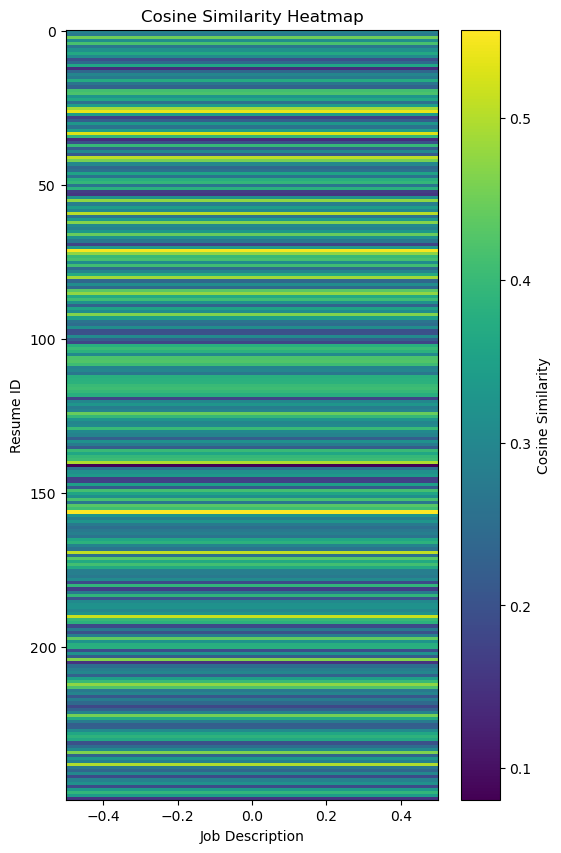

In [90]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt


resume_embeddings = np.array(resume_embeddings)
jd_embedding = np.array(jd_embedding)


similarities = cosine_similarity(
    resume_embeddings,
    jd_embedding.reshape(1, -1)
)

plt.figure(figsize=(6, 10))

plt.imshow(similarities, aspect="auto", cmap="viridis")

plt.colorbar(label="Cosine Similarity")

plt.xlabel("Job Description")
plt.ylabel("Resume ID")

plt.title("Cosine Similarity Heatmap")

plt.show()

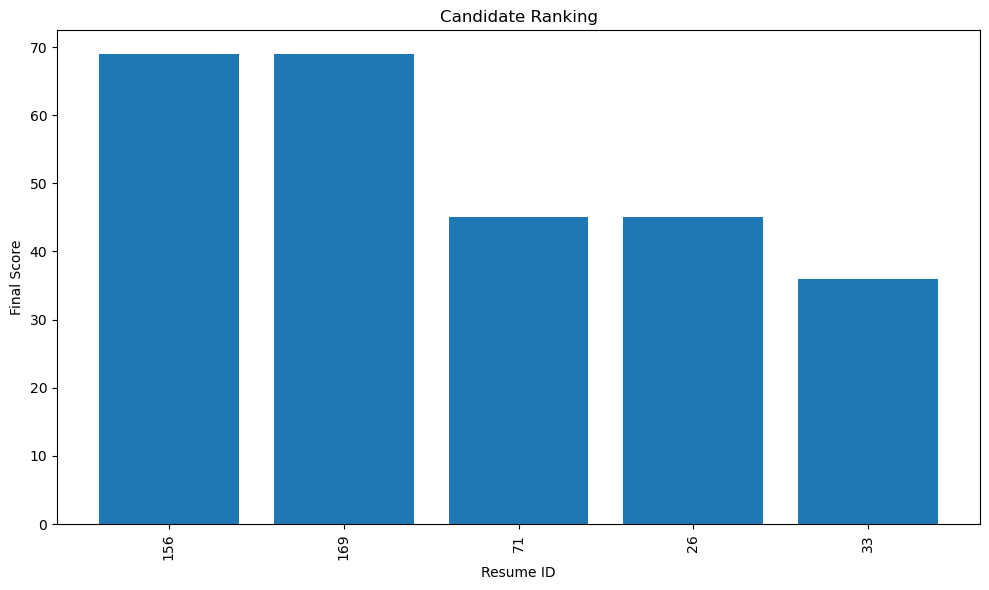

In [89]:
ranking_df = results_df.sort_values(
    by="Final Score",
    ascending=False
)

plt.figure(figsize=(10,6))

plt.bar(
    ranking_df["Resume ID"].astype(str),
    ranking_df["Final Score"]
)

plt.xticks(rotation=90)

plt.xlabel("Resume ID")

plt.ylabel("Final Score")

plt.title("Candidate Ranking")

plt.tight_layout()

plt.show()